#### 第六次作業：「串聯與並聯」元件的可靠度分析與模擬
姓名：陳維萱</font>

學號：411180015</font>

作品目標：本作品旨在透過數值模擬與參數估計方法，探討可靠性工程中串聯與並聯系統的可靠度分布特性。以數學推導與程式實現為基礎，分別研究兩個元件串聯和並聯後的新可靠度隨機變數，並利用 Beta 分布近似其分布特性。本作品結合 MLE 法和 Method of Moments 方法，進行參數估計，驗證理論推導的合理性，提供可靠性系統設計的量化依據，並促進對串聯與並聯結構的可靠度提升策略的深入理解。





<hr>
<font color=#EF9520> （一）串聯元件的可靠度模擬與 Beta 分布參數估計 </font>

- 令 Z=XY 代表兩個不同元件， X, Y 串聯後的新元件的可靠度隨機變數，以已知的分配（貝他分配）近似轉換後的隨機變數的分配 f(z)，接著利用最相似 PDF 函數的概念找到最接近的 beta (a, b) 分配，也就是 \[
$\min_{a,b>0}$ $\int_0^1 (f(z) - \beta(z|a,b))^2$ $\;dz$
\] ，本實驗模擬了兩個 Beta 分布的隨機變數 X 和 Y 分別代表元件的可靠度，並計算其串聯系統的可靠度 Z=X*Y ， 我們透過生成大量的樣本Z採用最大似然估計 (MLE)、矩法 (MM)、以及數值最小化方法，估計Z所屬的 Beta 分布參數，輸出估計結果值 a, b，並繪製pdf圖來比較這些方法的表現。

<hr>

MLE estimates: a = 7.641468, b = 4.023427
Optimal parameters: a = 7.620093096544278, b = 4.025266762505314
Method of Moments estimates: a = 7.643975827874924, b = 4.026099923884975


/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_97182/2942835843.py:67: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(z, stats.beta.pdf(z, a1, b1), 'r-', lw=2, alpha=0.6, label='Beta PDF (a1, b1) for X', linestyle='dashed')
/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_97182/2942835843.py:68: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "y-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(z, stats.beta.pdf(z, a2, b2), 'y-', lw=2, alpha=0.6, label='Beta PDF (a2, b2) for Y', linestyle='dashed')


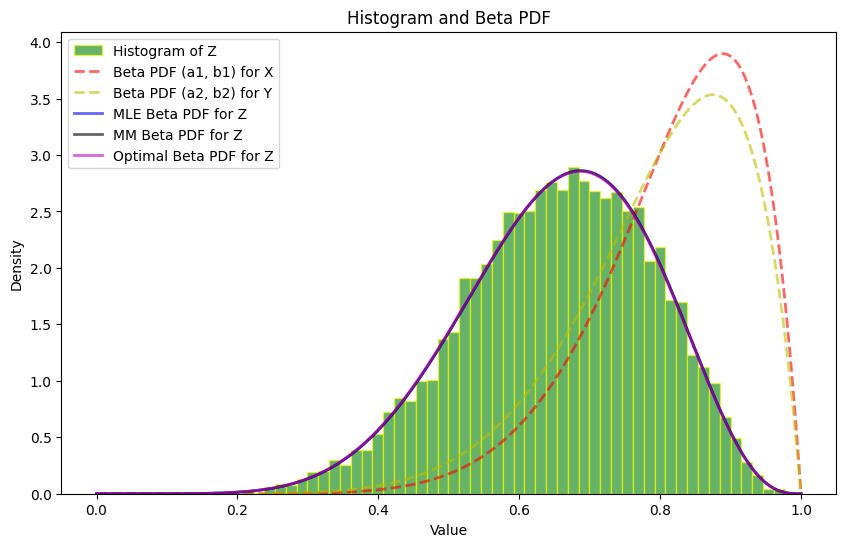

In [19]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# 參數
a1, b1, a2, b2 = 9, 2, 8, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
y = np.random.beta(a2, b2, N)
Z = x * y

# 使用 MLE 估計 Z 的 Beta 分佈參數
a_mle, b_mle, loc, scale = stats.beta.fit(Z, floc=0, fscale=1)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 定義 f(z) 函數
def f(z):
    integrand = lambda y: stats.beta.pdf(y, a2, b2) * stats.beta.pdf(z / y, a1, b1) / y
    result, _ = quad(integrand, z, 1)
    return result

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 1)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 繪製樣本的柱狀圖和 Beta PDF 函數線
plt.figure(figsize=(10, 6))
z = np.linspace(0, 1, 1000)
plt.hist(Z, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Z', edgecolor='yellow')
plt.plot(z, stats.beta.pdf(z, a1, b1), 'r-', lw=2, alpha=0.6, label='Beta PDF (a1, b1) for X', linestyle='dashed')
plt.plot(z, stats.beta.pdf(z, a2, b2), 'y-', lw=2, alpha=0.6, label='Beta PDF (a2, b2) for Y', linestyle='dashed')
plt.plot(z, stats.beta.pdf(z, a_mle, b_mle), 'b-', lw=2, alpha=0.6, label='MLE Beta PDF for Z')
plt.plot(z, stats.beta.pdf(z, a_mm, b_mm), 'k-', lw=2, alpha=0.6, label='MM Beta PDF for Z')
plt.plot(z, stats.beta.pdf(z, a_opt, b_opt), 'm-', lw=2, alpha=0.6, label='Optimal Beta PDF for Z')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Beta PDF')
plt.legend()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- MM 法相較其他估計法，估計較不精確。
>- MLE 方法是標準化的參數估計工具，通常是較為穩健的選擇。


<hr>
<font color=#EF9520> （二）並聯元件可靠度分析與 Beta 分布參數估計 </font>

- 令 \[ 
Z = 1 - (1 - X)^2 
\]代表兩個相同元件 X 並聯後的新元件的可靠度隨機變數，並推導出其PDF函數 $f_Z(z) = \frac{f_X(1 - \sqrt{1 - Z})}{2\sqrt{1 - Z}}$ ，以已知的分配（貝他分配）近似轉換後的隨機變數的分配 f(z)： 此為 PDF 函數配適的最小值問題，\[
$\min_{a,b>0}$ $\int_0^1 (f(z) - \beta(z|a,b))^2$ $\;dz$
\]，並使用數值方法模擬 Z 的樣本分布，以最大似然估計 (MLE) 和矩法 (MM) 估計 Beta 分布參數，輸出估計結果並繪製其pdf圖來比較這些方法的表現。

<hr>

MLE estimates: a = 15.630586, b = 0.743685
Method of Moments estimates: a = 12.982952775877475, b = 0.6132045944720279
Optimal parameters: a = 14.354995047716109, b = 0.6446260449180691


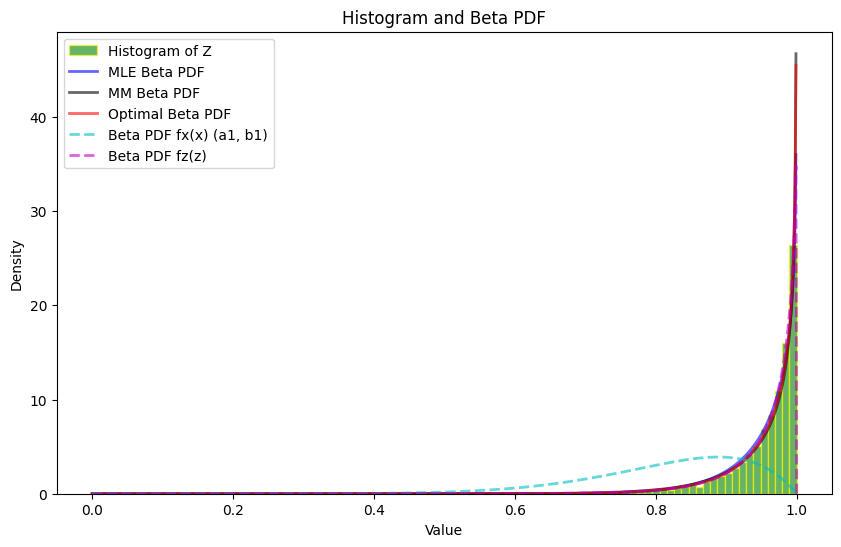

In [18]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# 參數
a1, b1 = 9, 2
N = 10000

# 生成樣本
x = np.random.beta(a1, b1, N)
Z = 1 - (1 - x)**2

# 使用 MLE 估計 Z 的 Beta 分佈參數
def mle_estimate(data):
    a_mle, b_mle, loc, scale = stats.beta.fit(data, floc=0, fscale=1)
    return a_mle, b_mle

a_mle, b_mle = mle_estimate(Z)
print('MLE estimates: a = %f, b = %f' % (a_mle, b_mle))

# 使用 Method of Moments 估計參數
def method_of_moments(data):
    mean = np.mean(data)
    var = np.var(data)
    a = mean * (mean * (1 - mean) / var - 1)
    b = (1 - mean) * (mean * (1 - mean) / var - 1)
    return a, b

a_mm, b_mm = method_of_moments(Z)
print(f"Method of Moments estimates: a = {a_mm}, b = {b_mm}")

# 定義轉換後的隨機變數的分配函數 f(z)
def f(z):
    if z == 1:
        return 0  # 避免分母為零
    return stats.beta.pdf(1 - np.sqrt(1 - z), a1, b1) / (2 * np.sqrt(1 - z))

# 定義 Beta 分佈函數 beta(z|a,b)
def beta_pdf(z, a, b):
    return stats.beta.pdf(z, a, b)

# 定義目標函數
def objective(params):
    a, b = params
    if a <= 0 or b <= 0:
        return np.inf  # 確保 a 和 b 都是正數
    integrand = lambda z: (f(z) - beta_pdf(z, a, b))**2
    result, _ = quad(integrand, 0, 0.95, epsabs=1e-9, epsrel=1e-9)
    return result

# 設定初始參數
initial_params = [1, 1]

# 使用 scipy.optimize.minimize 進行優化
result = minimize(objective, initial_params, bounds=[(1e-6, None), (1e-6, None)])

# 顯示結果
if result.success:
    a_opt, b_opt = result.x
    print(f"Optimal parameters: a = {a_opt}, b = {b_opt}")
else:
    print("Optimization failed.")

# 繪製樣本的柱狀圖和 Beta PDF 函數線
z = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))
plt.hist(Z, bins=50, density=True, alpha=0.6, color='g', label='Histogram of Z', edgecolor='yellow')
plt.plot(z, stats.beta.pdf(z, a_mle, b_mle), 'b-', lw=2, alpha=0.6, label='MLE Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_mm, b_mm), 'k-', lw=2, alpha=0.6, label='MM Beta PDF')
plt.plot(z, stats.beta.pdf(z, a_opt, b_opt), 'r-', lw=2, alpha=0.6, label='Optimal Beta PDF')

# 繪製 fx(x) 和 fz(z) 的 Beta PDF 函數線
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, stats.beta.pdf(x_vals, a1, b1), 'c--', lw=2, alpha=0.6, label='Beta PDF fx(x) (a1, b1)')
plt.plot(z, [f(val) for val in z], 'm--', lw=2, alpha=0.6, label='Beta PDF fz(z)')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Beta PDF')
plt.legend()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- Z 的分布與 Beta 分布高度吻合，驗證了 fz(z) 的推導合理性。
>- MLE方法估計適配效果更勝MM法
